<a href="https://colab.research.google.com/github/adminsanjay/ML-projects/blob/main/Fake_News_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###** Fake News Detection**

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("clmentbisaillon/fake-and-real-news-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'fake-and-real-news-dataset' dataset.
Path to dataset files: /kaggle/input/fake-and-real-news-dataset


In [2]:
import pandas as pd
import numpy as np
import spacy

nlp = spacy.load("en_core_web_sm")

In [3]:
# ==============================
# 2. Load ISOT Dataset
# ==============================
true_df = pd.read_csv(path+'/True.csv')
fake_df = pd.read_csv(path+'/Fake.csv')

# Add labels
true_df["label"] = 0   # Reliable
fake_df["label"] = 1   # Unreliable

# Combine datasets
df = pd.concat([true_df, fake_df], ignore_index=True)

# Shuffle dataset
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Optional: Take balanced subset (1000 each)
true_sample = df[df["label"] == 0].sample(1000, random_state=42)
fake_sample = df[df["label"] == 1].sample(1000, random_state=42)

df = pd.concat([true_sample, fake_sample]).reset_index(drop=True)

print("Dataset shape:", df.shape)
print(df["label"].value_counts())

Dataset shape: (2000, 5)
label
0    1000
1    1000
Name: count, dtype: int64


In [4]:
# ==============================
# 3. Custom Stop-word Strategy
# ==============================

# Default stopwords
stopwords = nlp.Defaults.stop_words

# Keep important stylistic words
retain_words = {"i", "we", "you", "they", "he", "she"}

# Final stopword list
custom_stopwords = stopwords - retain_words

In [5]:
# ==============================
# 4. Preprocessing Function
# ==============================

def preprocess_text(text):
    doc = nlp(text)

    tokens = []
    lemmas = []

    for token in doc:

        # Keep punctuation (!, ?)
        if token.text in ["!", "?"]:
            tokens.append(token.text)
            lemmas.append(token.text)
            continue

        # Skip spaces
        if token.is_space:
            continue

        # Remove stopwords (except retained ones)
        if token.text.lower() in custom_stopwords:
            continue

        # Keep token
        tokens.append(token.text)

        # Lemmatization
        lemmas.append(token.lemma_.lower())

    return {
        "tokens": tokens,
        "lemmas": lemmas,
        "sentence_count": len(list(doc.sents))
    }

In [6]:
# ==============================
# 5. Apply Preprocessing
# ==============================

processed_data = df["text"].apply(preprocess_text)

# Convert to DataFrame
processed_df = processed_data.apply(pd.Series)

# Merge with original data
df = pd.concat([df, processed_df], axis=1)

print(df.head())

                                               title  \
0  Gunfire heard in Eritrea's capital as protests...   
1  Merkel allies fret over former East Germany's ...   
2  South Korea president says acquiring nukes wou...   
3  Bill to cloak U.S. 'dark money' seen as harmfu...   
4  Virtual tie raises doubts: Can Hillary Clinton...   

                                                text       subject  \
0  NAIROBI (Reuters) - The U.S. embassy in Eritre...     worldnews   
1  BERLIN (Reuters) - The premiers of two regions...     worldnews   
2  SEOUL (Reuters) - If South Korea develops nucl...  politicsNews   
3  WASHINGTON (Reuters) - Fighting charity fraud ...  politicsNews   
4  DES MOINES, Iowa (Reuters) - Hillary Clinton’s...  politicsNews   

                  date  label  \
0    November 1, 2017       0   
1  September 30, 2017       0   
2    January 13, 2016       0   
3        May 24, 2016       0   
4    February 2, 2016       0   

                                           

In [7]:
# ==============================
# 6. Example Output
# ==============================

sample = df.iloc[0]

print("Original Text:\n", sample["text"][:300])
print("\nTokens:\n", sample["tokens"][:30])
print("\nLemmas:\n", sample["lemmas"][:30])
print("\nSentence Count:", sample["sentence_count"])

Original Text:
 NAIROBI (Reuters) - The U.S. embassy in Eritrea said it has received reports of gunfire in several parts of the capital, Asmara, after protests erupted in one of Africa s most secretive nations.  The embassy advises U.S. citizens to avoid the downtown area where protests appear to be more prevalent,

Tokens:
 ['NAIROBI', '(', 'Reuters', ')', '-', 'U.S.', 'embassy', 'Eritrea', 'said', 'received', 'reports', 'gunfire', 'parts', 'capital', ',', 'Asmara', ',', 'protests', 'erupted', 'Africa', 's', 'secretive', 'nations', '.', 'embassy', 'advises', 'U.S.', 'citizens', 'avoid', 'downtown']

Lemmas:
 ['nairobi', '(', 'reuters', ')', '-', 'u.s.', 'embassy', 'eritrea', 'say', 'receive', 'report', 'gunfire', 'part', 'capital', ',', 'asmara', ',', 'protest', 'erupt', 'africa', 's', 'secretive', 'nation', '.', 'embassy', 'advise', 'u.s.', 'citizen', 'avoid', 'downtown']

Sentence Count: 11


**Phase 2: Feature Engineering via POS Tagging**

In [8]:
# ==============================
# Feature Extraction Function
# ==============================
def extract_pos_features(text):
    doc = nlp(str(text))

    total_tokens = 0

    # Counters
    superlative_count = 0
    proper_noun_count = 0
    first_person_count = 0
    third_person_count = 0

    for token in doc:

        # Ignore punctuation & spaces
        if token.is_punct or token.is_space:
            continue

        total_tokens += 1

        # --------------------------
        # Superlatives (JJS, RBS)
        # --------------------------
        if token.tag_ in ["JJS", "RBS"]:
            superlative_count += 1

        # --------------------------
        # Proper Nouns (NNP)
        # --------------------------
        if token.tag_ == "NNP":
            proper_noun_count += 1

        # --------------------------
        # Personal Pronouns
        # --------------------------
        word = token.text.lower()

        # First-person
        if word in ["i", "we", "us", "our"]:
            first_person_count += 1

        # Third-person
        if word in ["he", "she", "they", "them", "his", "her", "their"]:
            third_person_count += 1

    # Avoid division by zero
    if total_tokens == 0:
        total_tokens = 1

    # ==============================
    # Ratios (Final Features)
    # ==============================
    superlative_ratio = superlative_count / total_tokens
    proper_noun_ratio = proper_noun_count / total_tokens

    # Pronoun ratio (I/We vs He/She)
    if third_person_count == 0:
        pronoun_ratio = first_person_count
    else:
        pronoun_ratio = first_person_count / third_person_count

    return pd.Series({
        "superlative_ratio": superlative_ratio,
        "proper_noun_ratio": proper_noun_ratio,
        "pronoun_ratio": pronoun_ratio
    })


In [9]:
# ==============================
# Apply Feature Extraction
# ==============================
pos_features = df["text"].apply(extract_pos_features)

# Merge with main dataframe
df = pd.concat([df, pos_features], axis=1)

# ==============================
# Sample Output
# ==============================
print("\n--- POS FEATURES SAMPLE ---")
print(df[["superlative_ratio", "proper_noun_ratio", "pronoun_ratio"]].head())


--- POS FEATURES SAMPLE ---
   superlative_ratio  proper_noun_ratio  pronoun_ratio
0           0.008065           0.104839       0.000000
1           0.000000           0.141026       0.333333
2           0.000000           0.300000       0.000000
3           0.003871           0.114839       0.444444
4           0.000000           0.140827       0.000000


**Phase 3: Syntax Analysis**

In [10]:
import random

# ==============================
# 1. Sentence Length Analysis
# ==============================
def avg_sentence_length(text):
    doc = nlp(str(text))
    sentences = list(doc.sents)

    if len(sentences) == 0:
        return 0

    total_words = 0

    for sent in sentences:
        words = [token for token in sent if not token.is_punct and not token.is_space]
        total_words += len(words)

    return total_words / len(sentences)

# Apply to dataset
df["avg_sentence_length"] = df["text"].apply(avg_sentence_length)

print("\n--- Sentence Length Feature ---")
print(df["avg_sentence_length"].head())


--- Sentence Length Feature ---
0    22.545455
1    26.000000
2    23.333333
3    25.000000
4    26.689655
Name: avg_sentence_length, dtype: float64


In [11]:
# ==============================
# 2. Tree Depth (Dependency-Based Approximation)
# ==============================

def get_tree_depth(token):
    """Recursively find depth of dependency tree"""
    if len(list(token.children)) == 0:
        return 1
    else:
        return 1 + max(get_tree_depth(child) for child in token.children)

def avg_tree_depth(text):
    doc = nlp(str(text))
    depths = []

    for sent in doc.sents:
        root = sent.root
        depth = get_tree_depth(root)
        depths.append(depth)

    if len(depths) == 0:
        return 0

    return sum(depths) / len(depths)

# Apply to dataset
df["avg_tree_depth"] = df["text"].apply(avg_tree_depth)

print("\n--- Tree Depth Feature ---")
print(df["avg_tree_depth"].head())


--- Tree Depth Feature ---
0    7.272727
1    7.833333
2    6.666667
3    7.967742
4    8.103448
Name: avg_tree_depth, dtype: float64


In [12]:
# ==============================
# 3. Sample 50 Sentences per Class
# ==============================

def get_sample_sentences(df, label, n=50):
    texts = df[df["label"] == label]["text"].sample(n, random_state=42)
    sentences = []

    for text in texts:
        doc = nlp(str(text))
        for sent in doc.sents:
            sentences.append(sent.text)

    return sentences[:n]

real_sentences = get_sample_sentences(df, label=0, n=50)
fake_sentences = get_sample_sentences(df, label=1, n=50)

# ==============================
# 4. Compute Depth for Samples
# ==============================

def compute_sample_depth(sent_list):
    depths = []
    for sent in sent_list:
        doc = nlp(sent)
        root = list(doc.sents)[0].root
        depths.append(get_tree_depth(root))
    return np.mean(depths)

real_depth = compute_sample_depth(real_sentences)
fake_depth = compute_sample_depth(fake_sentences)

print("\n--- Hypothesis Testing ---")
print("Average Tree Depth (Real News):", real_depth)
print("Average Tree Depth (Fake News):", fake_depth)


--- Hypothesis Testing ---
Average Tree Depth (Real News): 8.0
Average Tree Depth (Fake News): 7.26


**Phase 4: Classification**

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from scipy.sparse import hstack

# ==============================
# 1. Prepare Data
# ==============================

X_text = df["text"]
y = df["label"]

# Linguistic Features
ling_features = df[[
    "superlative_ratio",
    "proper_noun_ratio",
    "pronoun_ratio",
    "avg_sentence_length",
    "avg_tree_depth"
]].fillna(0)

# Train-test split
X_train_text, X_test_text, X_train_ling, X_test_ling, y_train, y_test = train_test_split(
    X_text, ling_features, y, test_size=0.2, random_state=42
)

In [19]:
# ==============================
# 2. TF-IDF (Reduced dominance)
# ==============================

tfidf = TfidfVectorizer(max_features=2000)

X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)

In [20]:
# ==============================
# 3. Scale Linguistic Features
# ==============================

scaler = StandardScaler()

X_train_ling_scaled = scaler.fit_transform(X_train_ling)
X_test_ling_scaled = scaler.transform(X_test_ling)

In [21]:
# ==============================
# 4. Model 1: TF-IDF Only
# ==============================

model_tfidf = LogisticRegression(max_iter=1000)
model_tfidf.fit(X_train_tfidf, y_train)

y_pred_tfidf = model_tfidf.predict(X_test_tfidf)

acc_tfidf = accuracy_score(y_test, y_pred_tfidf)

print("\n--- Model 1: TF-IDF Only ---")
print("Accuracy:", acc_tfidf)
print(classification_report(y_test, y_pred_tfidf))


--- Model 1: TF-IDF Only ---
Accuracy: 0.9675
              precision    recall  f1-score   support

           0       0.96      0.97      0.97       199
           1       0.97      0.97      0.97       201

    accuracy                           0.97       400
   macro avg       0.97      0.97      0.97       400
weighted avg       0.97      0.97      0.97       400



In [22]:
# ==============================
# 5. Model 2: TF-IDF + Linguistic (Logistic Regression)
# ==============================

X_train_combined = hstack([X_train_tfidf, X_train_ling_scaled])
X_test_combined = hstack([X_test_tfidf, X_test_ling_scaled])

model_combined_lr = LogisticRegression(max_iter=1000)
model_combined_lr.fit(X_train_combined, y_train)

y_pred_combined_lr = model_combined_lr.predict(X_test_combined)

acc_combined_lr = accuracy_score(y_test, y_pred_combined_lr)

print("\n--- Model 2: TF-IDF + Linguistic (Logistic Regression) ---")
print("Accuracy:", acc_combined_lr)
print(classification_report(y_test, y_pred_combined_lr))


--- Model 2: TF-IDF + Linguistic (Logistic Regression) ---
Accuracy: 0.955
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       199
           1       0.96      0.96      0.96       201

    accuracy                           0.95       400
   macro avg       0.95      0.95      0.95       400
weighted avg       0.95      0.95      0.95       400



In [23]:
# ==============================
# 6. Model 3: TF-IDF + Linguistic (Random Forest)
# ==============================

model_combined_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_combined_rf.fit(X_train_combined, y_train)

y_pred_combined_rf = model_combined_rf.predict(X_test_combined)

acc_combined_rf = accuracy_score(y_test, y_pred_combined_rf)

print("\n--- Model 3: TF-IDF + Linguistic (Random Forest) ---")
print("Accuracy:", acc_combined_rf)
print(classification_report(y_test, y_pred_combined_rf))


--- Model 3: TF-IDF + Linguistic (Random Forest) ---
Accuracy: 0.99
              precision    recall  f1-score   support

           0       0.99      0.98      0.99       199
           1       0.99      1.00      0.99       201

    accuracy                           0.99       400
   macro avg       0.99      0.99      0.99       400
weighted avg       0.99      0.99      0.99       400



In [24]:
# ==============================
# 7. Final Comparison
# ==============================

print("\n--- FINAL COMPARISON ---")
print(f"TF-IDF Only: {acc_tfidf:.4f}")
print(f"TF-IDF + Ling (LR): {acc_combined_lr:.4f}")
print(f"TF-IDF + Ling (RF): {acc_combined_rf:.4f}")

best_model = max(acc_tfidf, acc_combined_lr, acc_combined_rf)

if best_model == acc_combined_rf:
    print("✅ Best Model: Random Forest with Linguistic Features")
elif best_model == acc_combined_lr:
    print("✅ Best Model: Logistic Regression with Linguistic Features")
else:
    print("⚠️ Best Model: TF-IDF Only (Dataset is strongly keyword-driven)")


--- FINAL COMPARISON ---
TF-IDF Only: 0.9675
TF-IDF + Ling (LR): 0.9550
TF-IDF + Ling (RF): 0.9900
✅ Best Model: Random Forest with Linguistic Features


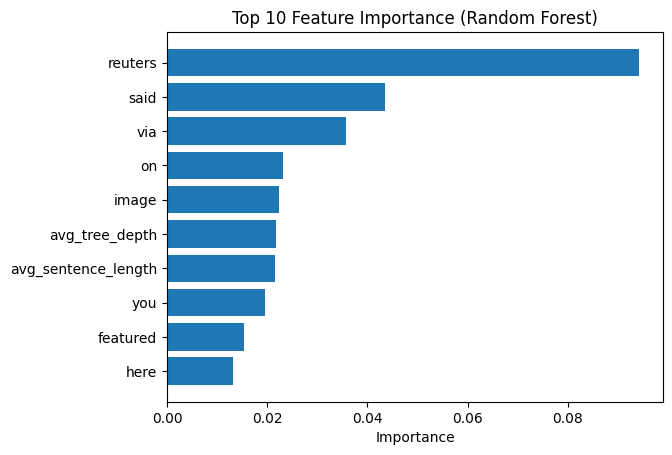

In [25]:
# ==============================
# REAL Feature Importance (from trained RF)
# ==============================

import matplotlib.pyplot as plt

# Get feature names
tfidf_features = tfidf.get_feature_names_out()
ling_features_names = [
    "superlative_ratio",
    "proper_noun_ratio",
    "pronoun_ratio",
    "avg_sentence_length",
    "avg_tree_depth"
]

# Combine names
all_features = list(tfidf_features) + ling_features_names

# Get importance
importances = model_combined_rf.feature_importances_

# Get top 10 important features
indices = np.argsort(importances)[-10:]

top_features = [all_features[i] for i in indices]
top_importances = importances[indices]

# Plot
plt.figure()
plt.barh(top_features, top_importances)
plt.xlabel("Importance")
plt.title("Top 10 Feature Importance (Random Forest)")
plt.show()

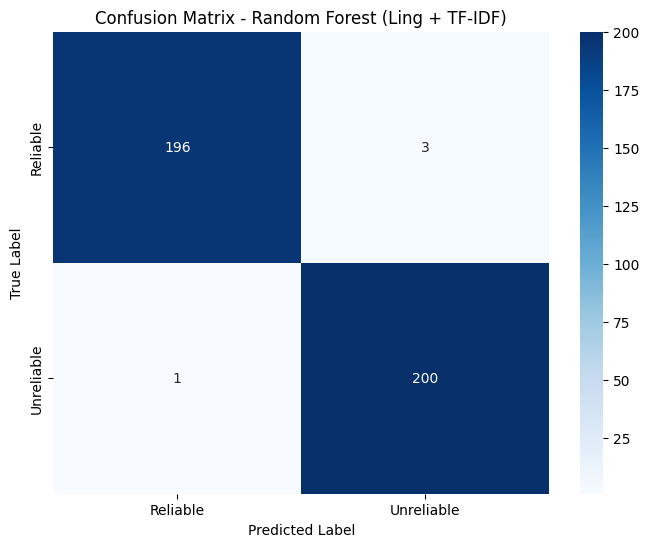

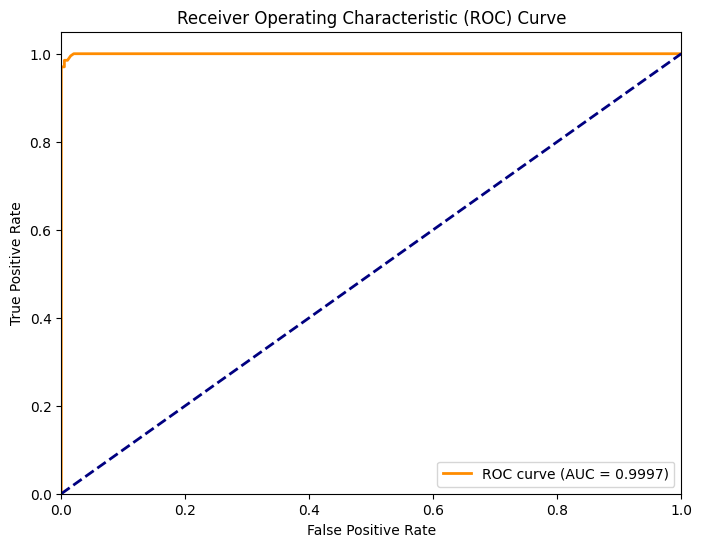

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
cm = confusion_matrix(y_test, y_pred_combined_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Reliable', 'Unreliable'], yticklabels=['Reliable', 'Unreliable'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Random Forest (Ling + TF-IDF)')
plt.show()
y_prob_rf = model_combined_rf.predict_proba(X_test_combined)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

*superlative_ratio*

/tmp/ipykernel_10861/4225768958.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="label", y="superlative_ratio", data=df, palette="muted", inner="quartile")


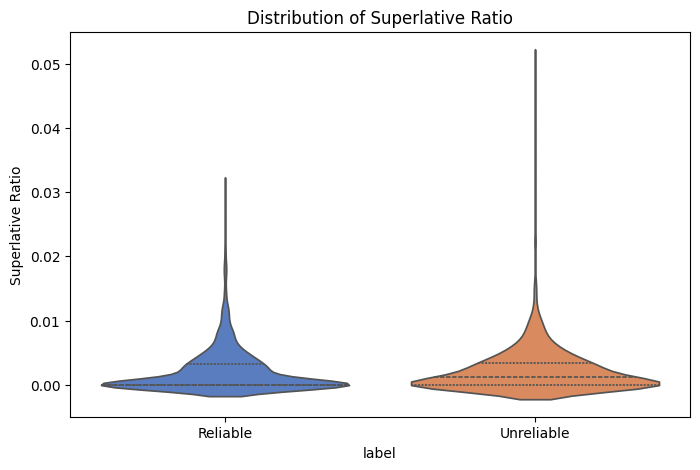

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
sns.violinplot(x="label", y="superlative_ratio", data=df, palette="muted", inner="quartile")
plt.title('Distribution of Superlative Ratio')
plt.xticks([0, 1], ['Reliable', 'Unreliable'])
plt.ylabel('Superlative Ratio')
plt.show()

Model Explainability: SHAP Summary Plot

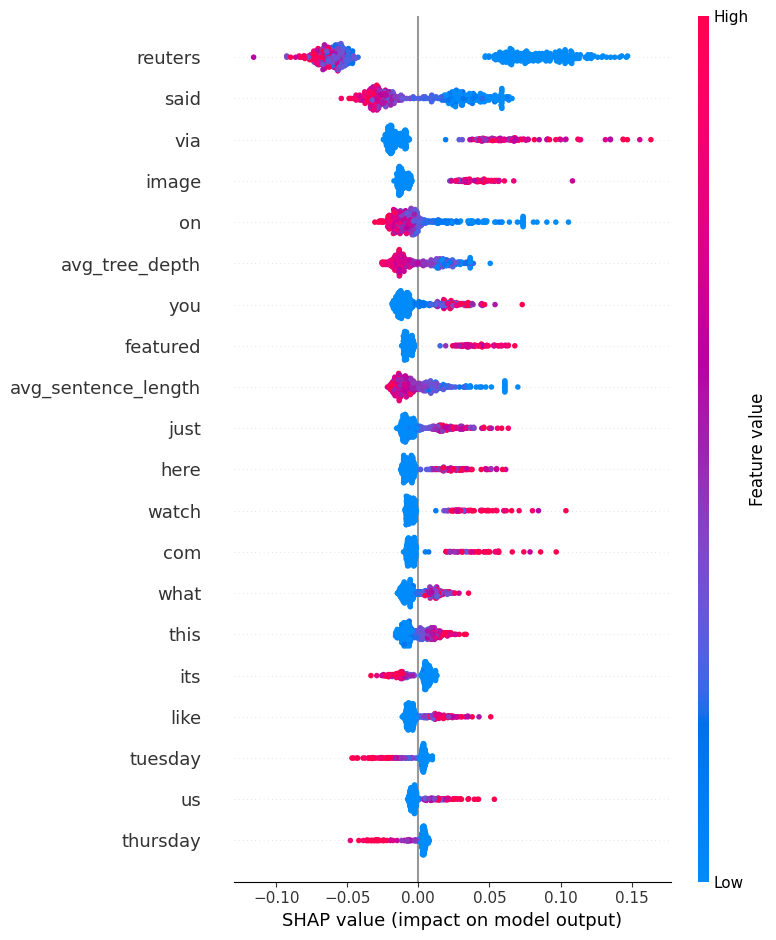

In [33]:
import shap
import numpy as np

# 1. Define features and dense matrix
all_features = list(tfidf.get_feature_names_out()) + [
    "superlative_ratio", "proper_noun_ratio", "pronoun_ratio",
    "avg_sentence_length", "avg_tree_depth"
]
X_test_dense = X_test_combined.toarray()

# 2. Calculate SHAP values
explainer = shap.TreeExplainer(model_combined_rf)
shap_values = explainer.shap_values(X_test_dense)

# 3. Handle SHAP version differences
if isinstance(shap_values, list):
    # Older SHAP versions: List of arrays
    shap_to_plot = shap_values[1]
else:
    # Newer SHAP versions: 3D NumPy array -> [all_rows, all_cols, class_1]
    shap_to_plot = shap_values[:, :, 1]

# 4. Generate the plot
shap.summary_plot(shap_to_plot, X_test_dense, feature_names=all_features)

Performance Nuance: Precision-Recall Curve & Probability KDE

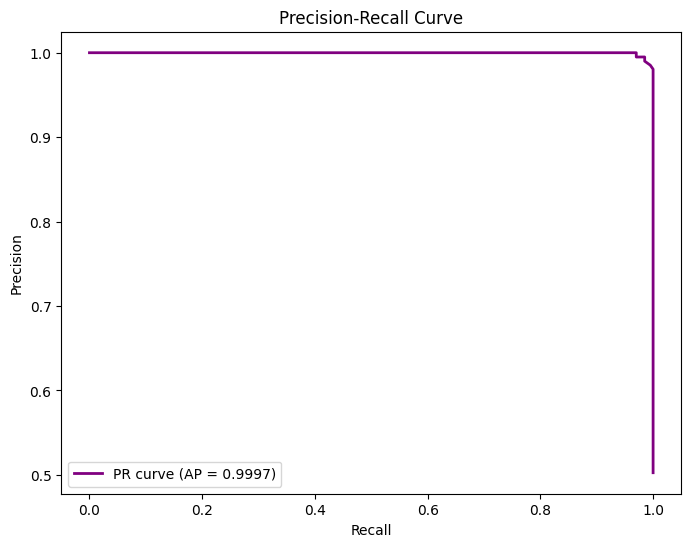

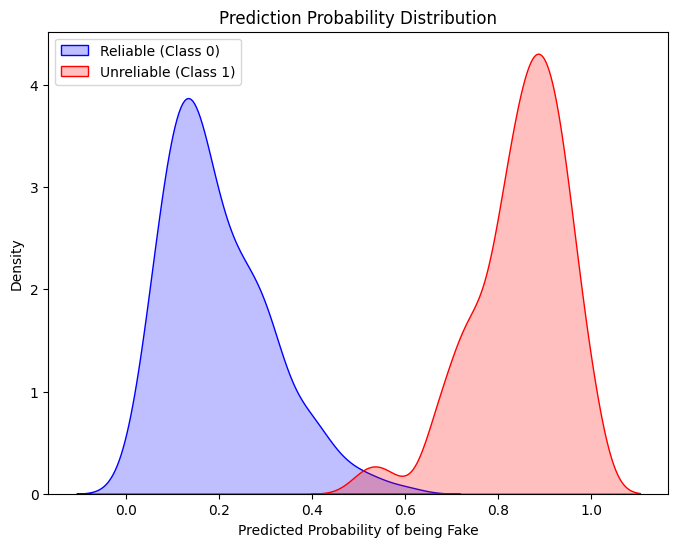

In [31]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import seaborn as sns
y_prob_rf = model_combined_rf.predict_proba(X_test_combined)[:, 1]
precision, recall, _ = precision_recall_curve(y_test, y_prob_rf)
ap_score = average_precision_score(y_test, y_prob_rf)
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='purple', lw=2, label=f'PR curve (AP = {ap_score:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()
plt.figure(figsize=(8, 6))
sns.kdeplot(y_prob_rf[y_test == 0], label="Reliable (Class 0)", color="blue", fill=True)
sns.kdeplot(y_prob_rf[y_test == 1], label="Unreliable (Class 1)", color="red", fill=True)
plt.xlabel("Predicted Probability of being Fake")
plt.ylabel("Density")
plt.title("Prediction Probability Distribution")
plt.legend()
plt.show()

Data & Feature Distribution: Linguistic Violin Plots

/tmp/ipykernel_10861/4155841887.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="label", y=feature, data=df, ax=axes[i], palette="muted", inner="quartile")
/tmp/ipykernel_10861/4155841887.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="label", y=feature, data=df, ax=axes[i], palette="muted", inner="quartile")
/tmp/ipykernel_10861/4155841887.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="label", y=feature, data=df, ax=axes[i], palette="muted", inner="quartile")


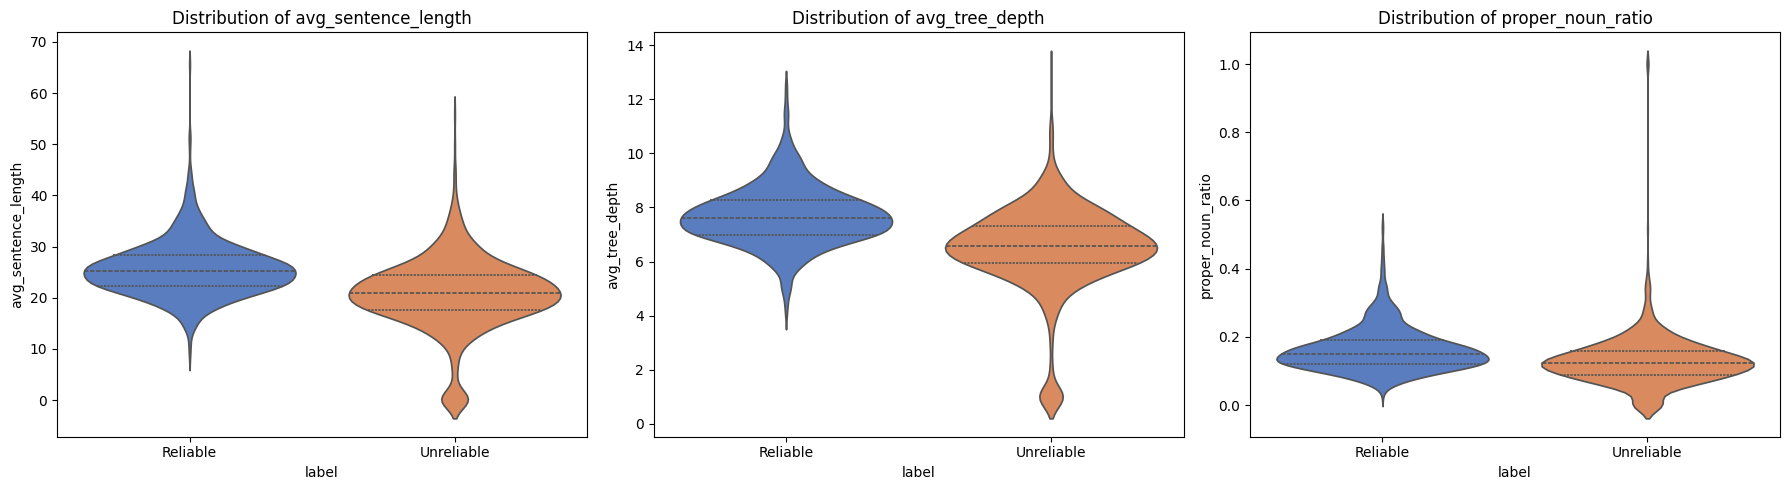

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt
features_to_plot = ["avg_sentence_length", "avg_tree_depth", "proper_noun_ratio"]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, feature in enumerate(features_to_plot):
    sns.violinplot(x="label", y=feature, data=df, ax=axes[i], palette="muted", inner="quartile")
    axes[i].set_title(f'Distribution of {feature}')
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Reliable', 'Unreliable'])
plt.tight_layout()
plt.show()